# Fase 3 — Preparação e Análise Estatística dos Dados

> **Metodologia:** CRISP-DM — *Data Preparation*
> **Projeto:** World Cup Analytics — Previsão de resultados da Copa do Mundo 2026
> **Autor:** Caio Falleiro
> **Entrada:** `worldcup_dataset.csv` (1 linha por partida, gerado por `build_dataset.py`)
> **Saída:** `worldcup_dataset_clean.csv` (base tratada + features de forma + flags de qualidade)

## Objetivo deste notebook
1. **Análise estatística descritiva** da base (EDA): distribuições, balanceamento do alvo, correlações.
2. **Diagnóstico e tratamento de valores nulos** — por *grupo de causa*, não global.
3. **Construção de features de forma** (médias móveis *leakage-safe* dos últimos N jogos) —
   os preditores realmente disponíveis **antes** de cada partida (Seção 3.5).
4. **Análise estatística inferencial**: testes de hipótese (Kruskal-Wallis, qui-quadrado) sobre
   as **features pré-jogo**, para comprovar quais separam as classes do alvo.
5. **Diagnóstico e tratamento de outliers** — distinguindo erro de medição de jogo legítimo atípico.
6. Produzir uma **base limpa, com features e documentada** pronta para a Fase 4 (Modelagem).

> **Base atual (jun/2026):** **1.138 partidas × 102 colunas** brutas. A base inclui os
> preditores de maior valor da literatura: **xG/xGA de time** (`home/away_expected_goals`),
> **ranking tipo FIFA das duas seleções** (`home/away_team_ranking`, `rank_diff`) e
> **estatísticas simétricas do visitante** (`away_*`). **982 (86%)** têm agregados de jogadores;
> **~590 (52%)** têm xG de time. Na Seção 3.5 derivamos as **features de forma** (`form_*`,
> `form_diff_*`), elevando a contagem final de colunas.

> **Dependências:** `pandas numpy matplotlib seaborn scipy` (ver `requirements.txt`).

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Path robusto: funciona rodando do repositorio (../output) ou do ZIP da entrega (./data)
def _resolve(name, search=('../output', 'data', '.')):
    for d in search:
        p = Path(d) / name
        if p.exists():
            return p
    return Path(search[0]) / name  # default p/ leitura; mesma pasta p/ escrita

DATA_IN  = _resolve('worldcup_dataset.csv')
DATA_OUT = DATA_IN.with_name('worldcup_dataset_clean.csv')
print('Lendo de:', DATA_IN.resolve())

df = pd.read_csv(DATA_IN)
print('Shape:', df.shape)
assert df['sofascore_event_id'].is_unique, 'ha eventos duplicados — rode build_dataset.py atualizado'
df.head(3)

Lendo de: C:\Users\Caio Falleiro\Códigos\WorldCupPrediction\output\worldcup_dataset.csv
Shape: (1138, 102)


,sofascore_event_id,match_date,competition,season,round_number,home_team,away_team,venue,venue_city,attendance,referee,score_home,score_away,score_home_ht,score_away_ht,home_team_ranking,away_team_ranking,result,home_possession_pct,home_shots_total,home_shots_on_target,home_shots_off_target,home_shots_blocked,home_big_chances,home_big_chances_missed,home_passes_total,home_passes_accurate,home_pass_accuracy_pct,home_long_balls_total,home_tackles,home_interceptions,home_clearances,home_goalkeeper_saves,home_dribbles_attempted,home_corners,home_free_kicks,home_goal_kicks,home_throw_ins,home_offsides,home_fouls,home_yellow_cards,home_red_cards,home_expected_goals,home_goals_prevented,home_big_chances_scored,home_touches_in_box,home_final_third_entries,home_recoveries,away_expected_goals,away_goals_prevented,away_possession_pct,away_shots_total,away_shots_on_target,away_big_chances,away_big_chances_scored,away_passes_total,away_pass_accuracy_pct,away_touches_in_box,away_final_third_entries,away_recoveries,away_corners,away_tackles,away_interceptions,away_n_players,home_n_players,away_rating_mean,home_rating_mean,away_rating_max,home_rating_max,away_rating_top3_mean,home_rating_top3_mean,away_rating_std,home_rating_std,away_xg_sum,home_xg_sum,away_xg_max,home_xg_max,away_xa_sum,home_xa_sum,away_goals_sum,home_goals_sum,away_assists_sum,home_assists_sum,away_key_passes_sum,home_key_passes_sum,away_shots_sum,home_shots_sum,away_dribbles_won_sum,home_dribbles_won_sum,away_aerial_won_sum,home_aerial_won_sum,away_aerial_total_sum,home_aerial_total_sum,away_att_rating_mean,home_att_rating_mean,away_mid_rating_mean,home_mid_rating_mean,away_def_rating_mean,home_def_rating_mean,away_gk_rating,home_gk_rating,rank_diff
0,11229802,2023-06-17T01:00:00+00:00,"CONCACAF Gold Cup, Preliminary Round",Gold Cup 2023,1.0,Curaçao,Saint Kitts and Nevis,Chase Stadium,Fort Lauderdale,NaN,NaN,3,4,NaN,NaN,82.0,152.0,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0
1,11436045,2023-09-07T22:00:00+00:00,"CONCACAF Nations League, League A, Group A",CONCACAF Nations League 23/24,1.0,Trinidad and Tobago,Curaçao,Hasely Crawford Stadium,Port Of Spain,NaN,NaN,1,0,NaN,NaN,102.0,82.0,L,33.0,8.0,2.0,5.0,1.0,2.0,1.0,288.0,220.0,76.4,22.0,19.0,10.0,18.0,3.0,4.0,7.0,17.0,6.0,10.0,0.0,14.0,3.0,NaN,NaN,NaN,1.0,NaN,43.0,63.0,NaN,NaN,67.0,14.0,3.0,1.0,0.0,593.0,NaN,NaN,72.0,63.0,6.0,16.0,6.0,14.0,16.0,6.914286,6.962500,8.3,7.8,7.633333,7.566667,0.523093,0.437988,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,13.0,7.0,14.0,8.0,5.0,4.0,7.0,8.0,7.0,13.0,6.833333,6.30,6.62,6.937500,7.320000,7.22,6.6,7.2,-20.0
2,11436051,2023-09-08T20:00:00+00:00,"CONCACAF Nations League, League A, Group B",CONCACAF Nations League 23/24,1.0,Haiti,Cuba,Estadio Panamericano,San Cristobal,NaN,NaN,0,0,NaN,NaN,83.0,164.0,D,65.0,10.0,4.0,5.0,1.0,2.0,2.0,468.0,408.0,87.2,21.0,13.0,11.0,11.0,3.0,5.0,4.0,9.0,7.0,16.0,2.0,15.0,1.0,NaN,NaN,NaN,NaN,NaN,62.0,57.0,NaN,NaN,35.0,10.0,3.0,0.0,NaN,248.0,NaN,NaN,36.0,58.0,5.0,8.0,5.0,16.0,14.0,6.893750,7.021429,8.1,7.8,7.666667,7.600000,0.450879,0.477459,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,7.0,7.0,10.0,10.0,10.0,5.0,11.0,11.0,9.0,17.0,6.650000,6.84,6.86,6.866667,6.883333,7.24,8.1,7.3,81.0


## 1. Visão geral e tipagem

`match_date` como datetime e separação de colunas de contexto/texto vs. numéricas, para que
IDs/datas não entrem na estatística descritiva.

In [23]:
df['match_date'] = pd.to_datetime(df['match_date'], utc=True, errors='coerce')
df = df.sort_values('match_date').reset_index(drop=True)

ID_COLS    = ['sofascore_event_id']
CTX_COLS   = ['match_date', 'competition', 'season', 'round_number',
              'home_team', 'away_team', 'venue', 'venue_city', 'attendance', 'referee']
TARGET     = 'result'
SCORE_COLS = ['score_home', 'score_away', 'score_home_ht', 'score_away_ht']
# rankings entram como feature; não tirar da análise numérica
num_cols = df.select_dtypes(include='number').columns.tolist()
FEATURE_NUM = [c for c in num_cols if c not in ID_COLS + SCORE_COLS + ['round_number', 'attendance']]

print(f'{len(FEATURE_NUM)} colunas numericas de feature')
print('Periodo:', df['match_date'].min(), '->', df['match_date'].max())
df.dtypes.value_counts()

86 colunas numericas de feature
Periodo: 2023-06-17 01:00:00+00:00 -> 2026-06-21 22:00:00+00:00


float64                90
str                     8
int64                   3
datetime64[us, UTC]     1
Name: count, dtype: int64

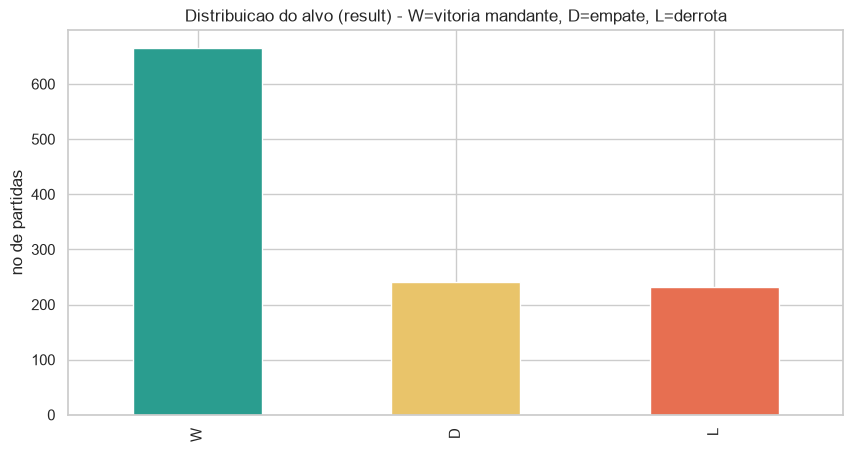

{'W': 0.584, 'D': 0.212, 'L': 0.204}


In [24]:
ax = df[TARGET].value_counts().reindex(['W','D','L']).plot(kind='bar', color=['#2a9d8f','#e9c46a','#e76f51'])
ax.set_title('Distribuicao do alvo (result) - W=vitoria mandante, D=empate, L=derrota')
ax.set_xlabel(''); ax.set_ylabel('no de partidas'); plt.show()
print(df[TARGET].value_counts(normalize=True).round(3).to_dict())

**Leitura:** alvo **desbalanceado** — vitória do mandante (~58%) domina; empate (~21%) e
derrota (~20%) são minorias. Fase 4: usar **log-loss** e **F1 macro**, e `class_weight`/balanceamento.

> Na Copa a maioria dos jogos é em campo neutro → o "mando" é o lado mandante nominal; sinal
> de mando mais fraco que em ligas. Por isso o **ranking** e o **xG** ganham importância.

## 2. Diagnóstico de valores nulos

Classificamos cada coluna pela **causa** do nulo. Com a extensão de features, há um grupo novo
importante: as **features de alto valor com nulo MNAR** (xG de time, ranking) — que **não se
dropam** (diferente do xG de *jogador*, que é 89% nulo e sai).

In [25]:
n = len(df)
na = df.isna().sum(); na = na[na > 0].sort_values(ascending=False)
pd.DataFrame({'n_nulos': na, 'pct': (na / n * 100).round(1)}).head(70)

,n_nulos,pct
score_home_ht,1138,100.0
score_away_ht,1138,100.0
away_pass_accuracy_pct,1138,100.0
home_goals_prevented,1030,90.5
away_goals_prevented,1030,90.5
...,...,...
home_def_rating_mean,154,13.5
home_rating_std,154,13.5
home_rating_top3_mean,154,13.5
home_shots_sum,154,13.5


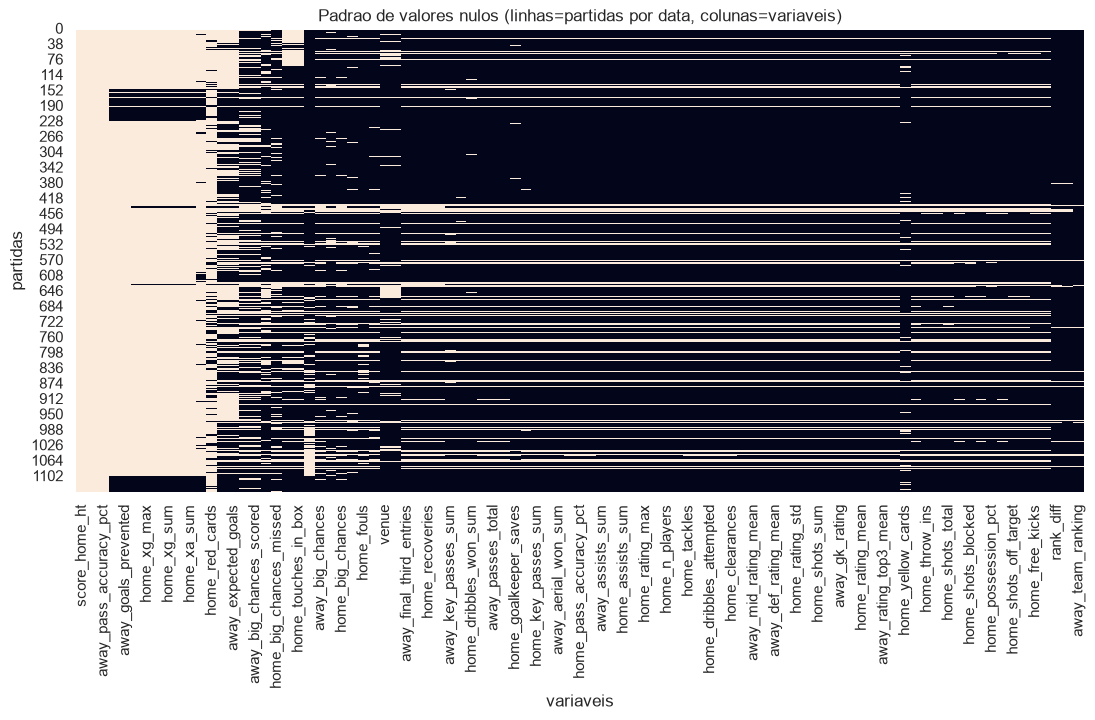

In [26]:
cols_na = na.index.tolist()
plt.figure(figsize=(13, 6))
sns.heatmap(df[cols_na].isna(), cbar=False, cmap='rocket')
plt.title('Padrao de valores nulos (linhas=partidas por data, colunas=variaveis)')
plt.xlabel('variaveis'); plt.ylabel('partidas'); plt.show()

**Diagnóstico — grupos de causa** (sobre 1.138 partidas)

| Grupo | Exemplos | % nulo | Tratamento |
|---|---|---|---|
| **A. Sem fonte (dropar)** | `score_*_ht` (100%), **xG de JOGADOR** `*_xg_*`/`*_xa_*` (89%), `attendance` (87%) | altíssimo | **Dropar** colunas |
| **A′. Alto valor MNAR (MANTER)** | **xG de TIME** `home/away_expected_goals` (48%), `goals_prevented` (91%) | médio-alto | **Manter** + flag `has_xg`; imputar na Fase 4 |
| **B. Nulo = zero** | `home_red_cards` (77%) e eventos raros | alto | **Imputar 0** (c/ checagem) |
| **C. MNAR por competição** | agregados de jogador (~14%), `match_stats` home/`away_*` (~13%) | médio | **Flags** + manter NaN |
| **D. Contexto / ranking** | `referee` (27%), `round_number` (20%), `ranking` (~3%) | baixo-médio | `"Unknown"` / manter |

> **Distinção crítica:** `expected_goals` (time) tem 48% nulo mas é **preditor nº 1 da
> literatura** — concentrado em competições menores sem xG na fonte (MNAR). Dropar seria
> jogar fora sinal forte. Mantemos + flag; a imputação fica na Fase 4 (mediana da competição).
> Já `home_xg_sum` (xG de *jogador*, 89% nulo) **sai** — cobertura insuficiente.

## 3. Tratamento de nulos

In [27]:
dfc = df.copy()

# --- Grupo A: dropar colunas sem fonte (inclui o xG de JOGADOR, nao o de time) ---
DROP_NO_SOURCE = ['score_home_ht', 'score_away_ht']
# Apenas os agregados de jogador (_xg_/_xa_) — NAO casa com 'expected_goals' (time)
DROP_PLAYER_XG = [c for c in dfc.columns if '_xg_' in c or '_xa_' in c]
dfc = dfc.drop(columns=DROP_NO_SOURCE + DROP_PLAYER_XG)
FEATURE_NUM = [c for c in FEATURE_NUM if c in dfc.columns]
print('Dropadas (sem fonte):', DROP_NO_SOURCE + DROP_PLAYER_XG)
print('xG de TIME preservado:', [c for c in dfc.columns if 'expected_goals' in c])

Dropadas (sem fonte): ['score_home_ht', 'score_away_ht', 'away_xg_sum', 'home_xg_sum', 'away_xg_max', 'home_xg_max', 'away_xa_sum', 'home_xa_sum']
xG de TIME preservado: ['home_expected_goals', 'away_expected_goals']


In [28]:
# --- Grupo B: nulo = zero (eventos de contagem ausentes, onde ha stats de time) ---
has_team_stats = dfc['home_possession_pct'].notna()
for col in ['home_red_cards', 'home_yellow_cards', 'home_offsides',
            'home_big_chances', 'home_big_chances_missed']:
    if col in dfc.columns:
        mask = dfc[col].isna() & has_team_stats
        dfc.loc[mask, col] = 0
        print(f'{col}: {int(mask.sum())} nulos -> 0')

home_red_cards: 792 nulos -> 0
home_yellow_cards: 65 nulos -> 0
home_offsides: 60 nulos -> 0
home_big_chances: 52 nulos -> 0
home_big_chances_missed: 136 nulos -> 0


In [29]:
# --- Grupos A'/C: FLAGS de qualidade (nao destrutivo) ---
dfc['has_team_stats']   = dfc['home_possession_pct'].notna().astype(int)
dfc['has_player_stats'] = dfc['home_rating_mean'].notna().astype(int)
dfc['has_xg']           = dfc['home_expected_goals'].notna().astype(int)
dfc['has_ranking']      = dfc['home_team_ranking'].notna().astype(int)

for f in ['has_team_stats','has_player_stats','has_xg','has_ranking']:
    print(f'{f:18s}: {int(dfc[f].sum())} ({dfc[f].mean()*100:.0f}%)')

has_team_stats    : 997 (88%)
has_player_stats  : 984 (86%)
has_xg            : 588 (52%)
has_ranking       : 1099 (97%)


**Decisão (Grupos A′/C):** não imputamos na base descritiva — `NaN` é honesto e as flags
`has_team_stats`/`has_player_stats`/`has_xg`/`has_ranking` registram a ausência.

Na **Fase 4**: imputar por **mediana da competição** + usar as flags como variável (boosting
trata `NaN` nativamente). O xG ausente é MNAR por competição, então a flag carrega sinal.

In [30]:
# --- Grupo D: contexto textual -> placeholder ---
for col in ['referee', 'venue', 'venue_city', 'season']:
    if col in dfc.columns:
        dfc[col] = dfc[col].fillna('Unknown')

na2 = dfc.isna().sum(); na2 = na2[na2 > 0].sort_values(ascending=False)
print('Colunas com nulos remanescentes (esperado: MNAR de jogador/time/xG):')
print((na2.head(15) / len(dfc) * 100).round(1).astype(str) + '%')

Colunas com nulos remanescentes (esperado: MNAR de jogador/time/xG):
away_pass_accuracy_pct     100.0%
home_goals_prevented        90.5%
away_goals_prevented        90.5%
attendance                  87.1%
home_expected_goals         48.3%
away_expected_goals         48.3%
away_big_chances_scored     33.0%
home_big_chances_scored     33.0%
home_touches_in_box         22.8%
away_touches_in_box         22.8%
round_number                19.7%
away_big_chances            17.4%
away_aerial_total_sum       16.5%
home_fouls                  16.4%
home_aerial_total_sum       15.9%
dtype: str


## 3.5 Construção de features de FORMA (médias móveis *leakage-safe*)

As estatísticas até aqui são **medidas durante a partida** — descrevem o que já aconteceu e
**não existem antes** de um jogo a prever. Para que a análise de significância (Seção 4.4) e a
modelagem (Fase 4) usem os **preditores realmente disponíveis pré-jogo**, construímos aqui as
**features de forma recente**: para cada seleção, a **média dos últimos `N=5` jogos**.

**Como evitamos vazamento (*leakage*):**
1. Reorganizamos a base em formato **longo** (1 linha por *seleção × partida*), para acompanhar
   cada time ao longo do tempo, jogando em casa ou fora.
2. Calculamos a média móvel com **`shift(1)`** — que **exclui a própria partida**, usando só os
   jogos **anteriores** (`rolling(5)`).
3. Trazemos de volta para 1 linha por partida (`home_form_*`, `away_form_*`) e criamos as
   **diferenças `form_diff_* = home − away`** — os preditores que a Fase 4 vai consumir.

> Métricas escolhidas (disponíveis para os dois lados): **pontos, gols feitos/sofridos, xG/xGA,
> posse, finalizações, finalizações no alvo, grandes chances, precisão de passe, rating médio e
> rating de ataque/defesa**. As primeiras partidas de cada seleção ficam com `NaN` (sem
> histórico) — registrado na flag `has_form`.

In [31]:
FORM_WINDOW = 5   # janela: ultimos N jogos
FORM_MINP   = 2   # minimo de jogos anteriores para calcular a forma

# metrica -> (coluna do mandante, coluna do visitante) — disponiveis simetricamente nos 2 lados
FORM_SRC = {
    'possession':  ('home_possession_pct',    'away_possession_pct'),
    'shots':       ('home_shots_total',        'away_shots_total'),
    'shots_on_t':  ('home_shots_on_target',    'away_shots_on_target'),
    'big_chances': ('home_big_chances',        'away_big_chances'),
    'pass_acc':    ('home_pass_accuracy_pct',  'away_pass_accuracy_pct'),
    'xg':          ('home_expected_goals',     'away_expected_goals'),
    'rating':      ('home_rating_mean',        'away_rating_mean'),
    'att_rating':  ('home_att_rating_mean',    'away_att_rating_mean'),
    'def_rating':  ('home_def_rating_mean',    'away_def_rating_mean'),
}

# 1) formato LONGO: 1 linha por (partida, selecao), na perspectiva "do proprio time"
def _side_rows(side):
    home = side == 'home'
    gf = dfc['score_home'] if home else dfc['score_away']
    ga = dfc['score_away'] if home else dfc['score_home']
    out = pd.DataFrame({
        'eid':  dfc['sofascore_event_id'],
        'date': dfc['match_date'],
        'team': dfc['home_team'] if home else dfc['away_team'],
        'side': side,
        'gf': gf, 'ga': ga,
        'points': np.select([gf > ga, gf == ga], [3, 1], default=0),
        'xga': dfc['away_expected_goals'] if home else dfc['home_expected_goals'],
    })
    for m, (hc, ac) in FORM_SRC.items():
        out[m] = dfc[hc] if home else dfc[ac]
    return out

long = pd.concat([_side_rows('home'), _side_rows('away')], ignore_index=True)
long = long.sort_values(['team', 'date']).reset_index(drop=True)

# 2) media movel dos N jogos ANTERIORES por selecao. shift(1) EXCLUI a propria partida
#    => construcao leakage-safe (so usa o passado)
ROLL_METRICS = ['points', 'gf', 'ga', 'xg', 'xga', 'possession', 'shots',
                'shots_on_t', 'big_chances', 'pass_acc', 'rating', 'att_rating', 'def_rating']
for m in ROLL_METRICS:
    long[f'form_{m}'] = (long.groupby('team')[m]
                             .transform(lambda s: s.shift(1)
                                                   .rolling(FORM_WINDOW, min_periods=FORM_MINP).mean()))

# 3) de volta a 1 linha por partida: colunas home_form_* e away_form_*
form_cols = [f'form_{m}' for m in ROLL_METRICS]
wide = long.pivot_table(index='eid', columns='side', values=form_cols)
wide.columns = [f'{side}_{col}' for col, side in wide.columns]   # ex.: home_form_points
dfc = dfc.merge(wide, left_on='sofascore_event_id', right_index=True, how='left')

# 4) features de DIFERENCA (mandante - visitante): os preditores PRE-JOGO do modelo
FORM_DIFF = []
for m in ROLL_METRICS:
    d = f'form_diff_{m}'
    dfc[d] = dfc[f'home_form_{m}'] - dfc[f'away_form_{m}']
    FORM_DIFF.append(d)

dfc['has_form'] = dfc[['home_form_points', 'away_form_points']].notna().all(axis=1).astype(int)
PRE_MATCH_FEATURES = FORM_DIFF + ['rank_diff']

print(f'{len(form_cols) * 2} colunas de forma (home/away) + {len(FORM_DIFF)} diffs criadas')
print(f'Partidas com forma nos dois lados (has_form=1): {int(dfc.has_form.sum())} de {len(dfc)}')
dfc[['home_team', 'away_team', 'form_diff_points', 'form_diff_xg', 'rank_diff']].tail(5)

26 colunas de forma (home/away) + 13 diffs criadas
Partidas com forma nos dois lados (has_form=1): 835 de 1138


,home_team,away_team,form_diff_points,form_diff_xg,rank_diff
1133,Ecuador,Curaçao,1.0,0.964500,59.0
1134,Tunisia,Japan,-1.8,-0.528333,-27.0
1135,Spain,Saudi Arabia,0.8,0.941333,59.0
1136,Belgium,Iran,0.2,NaN,11.0
1137,Uruguay,Cabo Verde,-1.2,-0.033333,51.0


## 4. Análise estatística descritiva

In [32]:
dfc[FEATURE_NUM].describe().T[['mean','std','min','25%','50%','75%','max']].round(2)

,mean,std,min,25%,50%,75%,max
home_team_ranking,48.44,42.54,1.00,17.00,37.00,67.00,211.00
away_team_ranking,55.63,41.55,1.00,23.00,47.00,77.75,211.00
home_possession_pct,52.92,14.32,0.00,42.00,54.00,64.00,86.00
home_shots_total,13.16,6.55,0.00,8.00,12.00,17.00,35.00
home_shots_on_target,4.67,2.97,0.00,3.00,4.00,6.00,17.00
...,...,...,...,...,...,...,...
away_def_rating_mean,6.77,0.39,5.28,6.54,6.78,7.04,8.16
home_def_rating_mean,6.92,0.39,5.48,6.70,6.94,7.17,8.22
away_gk_rating,6.98,0.74,3.70,6.50,6.90,7.40,10.00
home_gk_rating,6.94,0.61,4.90,6.60,6.90,7.30,9.80


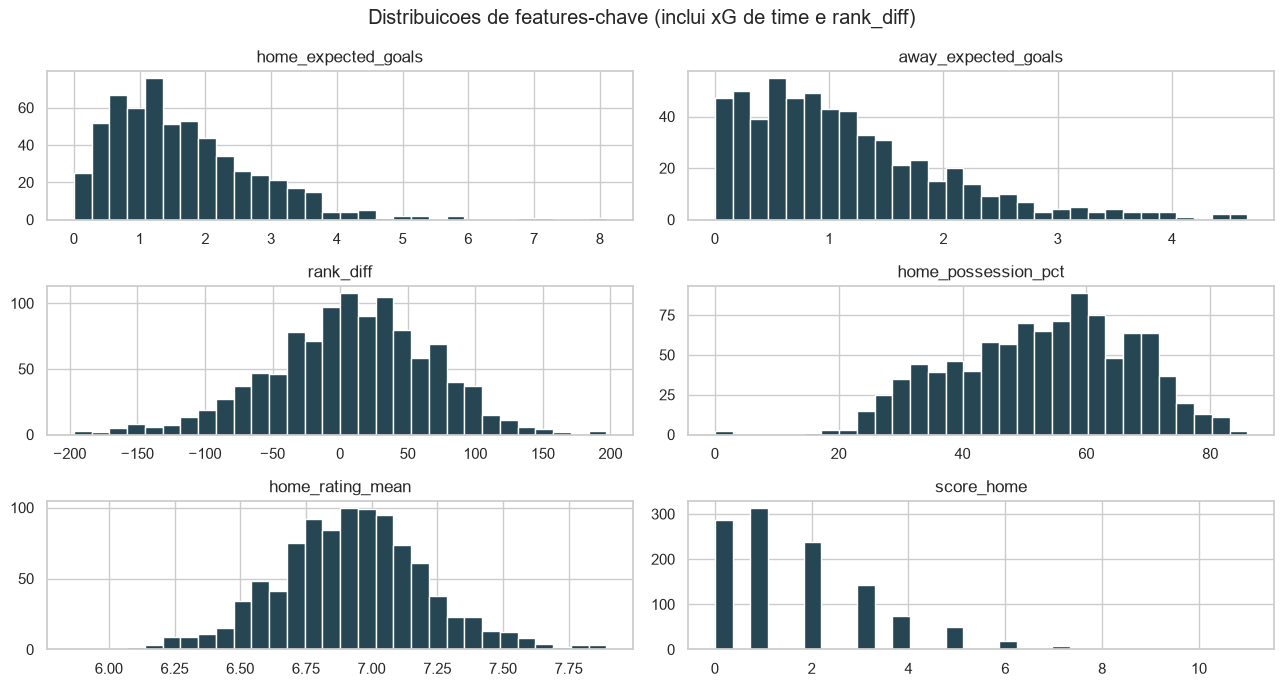

In [33]:
key = [c for c in ['home_expected_goals','away_expected_goals','rank_diff',
                   'home_possession_pct','home_rating_mean','score_home'] if c in dfc.columns]
dfc[key].hist(bins=30, figsize=(13, 7), color='#264653')
plt.suptitle('Distribuicoes de features-chave (inclui xG de time e rank_diff)')
plt.tight_layout(); plt.show()

In [34]:
# xG dos dois lados vs resultado — sanity check do novo preditor
sub = dfc.dropna(subset=['home_expected_goals','away_expected_goals'])
print('xG medio por resultado (do mandante):')
print(sub.groupby('result')[['home_expected_goals','away_expected_goals']].mean().round(2))

xG medio por resultado (do mandante):
        home_expected_goals  away_expected_goals
result                                          
D                      1.33                 1.00
L                      1.60                 1.13
W                      1.79                 1.21


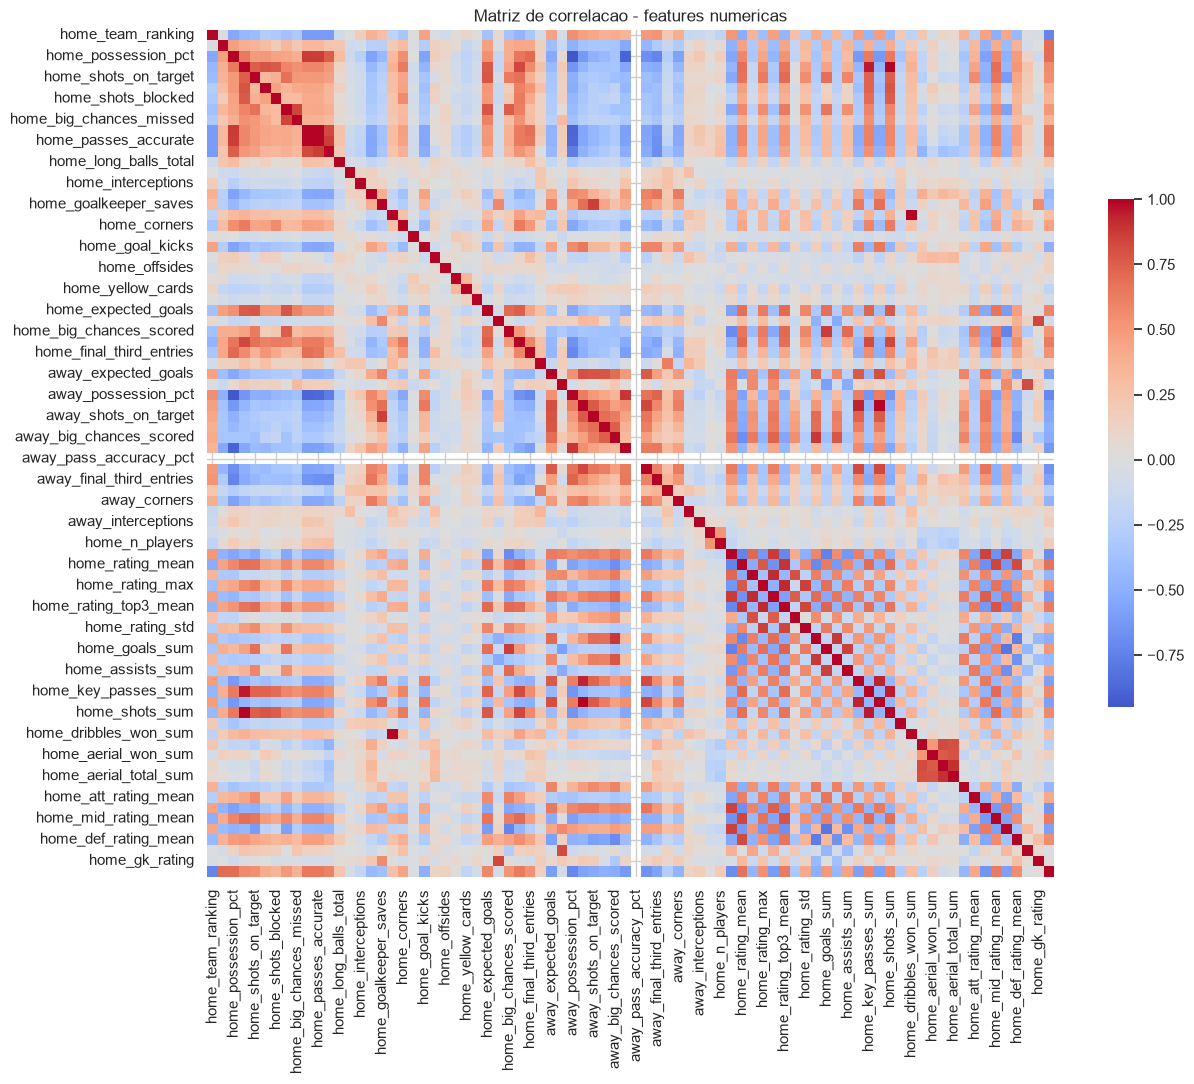

Pares com |correlacao| > 0.85:
away_shots_total         away_shots_sum            1.00
home_shots_total         home_shots_sum            1.00
home_dribbles_attempted  home_dribbles_won_sum     1.00
home_passes_total        home_passes_accurate      1.00
home_key_passes_sum      home_shots_sum            0.95
home_shots_total         home_key_passes_sum       0.95
away_key_passes_sum      away_shots_sum            0.93
away_shots_total         away_key_passes_sum       0.93
home_rating_max          home_rating_top3_mean     0.93
away_rating_max          away_rating_top3_mean     0.92
away_aerial_total_sum    home_aerial_total_sum     0.91
home_rating_mean         home_rating_top3_mean     0.90
away_possession_pct      away_passes_total         0.89
away_big_chances_scored  away_goals_sum            0.88
away_goals_sum           away_assists_sum          0.88
home_possession_pct      home_passes_total         0.88
away_rating_mean         away_rating_top3_mean     0.87
home_possession_p

In [35]:
corr = dfc[FEATURE_NUM].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': .6})
plt.title('Matriz de correlacao - features numericas'); plt.show()

cc = corr.where(~np.eye(len(corr), dtype=bool)).stack()
print('Pares com |correlacao| > 0.85:')
print(cc[cc.abs() > 0.85].drop_duplicates().sort_values(ascending=False).round(2).head(20))

**Leitura:** pares quase perfeitos = **redundância de fonte** (mesmo conceito vindo de
`match_stats` e do agregado de jogadores), ex.: `home_shots_total` ≈ `home_shots_sum`. Na
Fase 4, manter só uma de cada par. O **xG médio por resultado** (célula acima) serve de sanity
check: o mandante tende a ter xG maior quando vence — sinal coerente.

## 4.4 Análise estatística inferencial (testes de hipótese)

A estatística descritiva mostra *padrões*; os testes abaixo medem se eles são
**estatisticamente significativos**. **Ponto-chave:** testamos a significância sobre as
**features PRÉ-JOGO** construídas na Seção 3.5 (`form_diff_*` e `rank_diff`) — e **não** sobre
estatísticas medidas durante a partida (que separariam o resultado de forma quase tautológica,
além de não existirem antes do jogo). Assim a triagem de features já vale para a Fase 4.

Como várias features **não são normais**, usamos testes **não-paramétricos**:

- **Kruskal-Wallis** — *H₀:* a distribuição da feature pré-jogo é igual entre `W`, `D` e `L`.
  Rejeitar H₀ (p < 0,05) indica que a variável **separa** os resultados *antes* da bola rolar.
- **Qui-quadrado de independência** — *H₀:* o favoritismo no ranking é independente do resultado.

C:\Users\Caio Falleiro\AppData\Local\Temp\ipykernel_476\897095065.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfc, x='result', y=c, order=order, palette=pal, ax=ax)
C:\Users\Caio Falleiro\AppData\Local\Temp\ipykernel_476\897095065.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfc, x='result', y=c, order=order, palette=pal, ax=ax)
C:\Users\Caio Falleiro\AppData\Local\Temp\ipykernel_476\897095065.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfc, x='result', y=c, order=order, palette=pal, ax=ax)
C:\Users\Caio

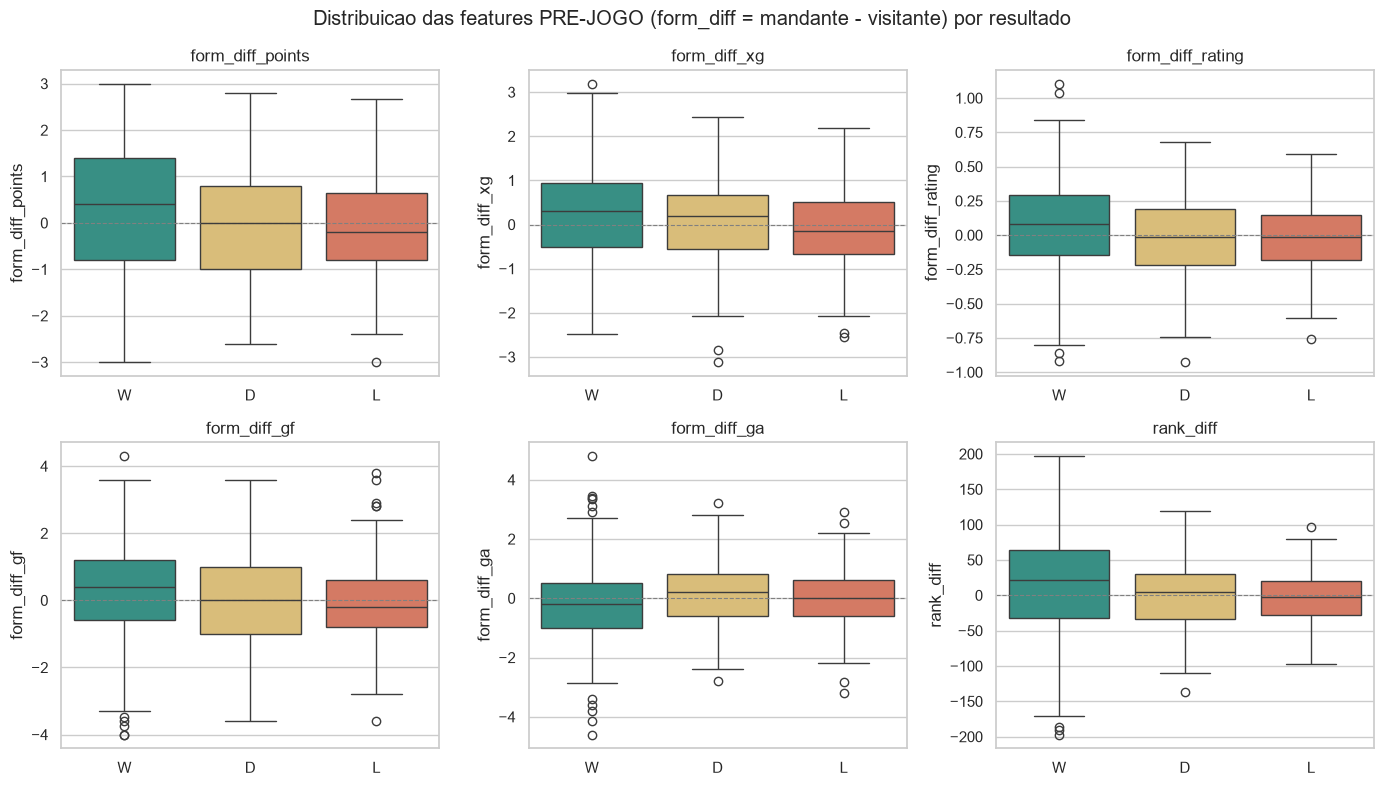

In [36]:
# Analise bivariada: distribuicao das features PRE-JOGO por resultado (W/D/L)
biv = [c for c in ['form_diff_points', 'form_diff_xg', 'form_diff_rating',
                   'form_diff_gf', 'form_diff_ga', 'rank_diff']
       if c in dfc.columns]
order = ['W', 'D', 'L']
pal = {'W': '#2a9d8f', 'D': '#e9c46a', 'L': '#e76f51'}
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, c in zip(axes.ravel(), biv):
    sns.boxplot(data=dfc, x='result', y=c, order=order, palette=pal, ax=ax)
    ax.axhline(0, color='gray', lw=.8, ls='--')
    ax.set_title(c); ax.set_xlabel('')
plt.suptitle('Distribuicao das features PRE-JOGO (form_diff = mandante - visitante) por resultado')
plt.tight_layout(); plt.show()

In [37]:
from scipy import stats

# Kruskal-Wallis SOBRE AS FEATURES PRE-JOGO (forma + ranking) — leakage-safe.
# H0: a distribuicao da feature e igual entre W/D/L.
def kruskal_by_target(col):
    groups = [dfc.loc[dfc['result'] == g, col].dropna() for g in ['W', 'D', 'L']]
    if min(len(x) for x in groups) < 10:      # amostra minima por grupo
        return np.nan, np.nan
    return stats.kruskal(*groups)

rows = [(c, *kruskal_by_target(c)) for c in PRE_MATCH_FEATURES]
kw = (pd.DataFrame(rows, columns=['feature', 'H', 'p_value'])
        .dropna()
        .sort_values('p_value')
        .reset_index(drop=True))
kw['significativo_5pct'] = kw['p_value'] < 0.05
print(f"{int(kw['significativo_5pct'].sum())}/{len(kw)} features PRE-JOGO separam o resultado (p < 0.05)")
print('Ranking de poder de separacao (menor p-valor = melhor preditor pre-jogo):')
kw.assign(p_value=lambda d: d['p_value'].map('{:.2e}'.format)).round({'H': 1})

14/14 features PRE-JOGO separam o resultado (p < 0.05)
Ranking de poder de separacao (menor p-valor = melhor preditor pre-jogo):


,feature,H,p_value,significativo_5pct
0,rank_diff,29.2,4.56e-07,True
1,form_diff_possession,22.2,1.54e-05,True
2,form_diff_points,20.9,2.90e-05,True
3,form_diff_pass_acc,17.6,1.54e-04,True
4,form_diff_xga,17.5,1.58e-04,True
5,form_diff_def_rating,15.3,4.75e-04,True
6,form_diff_ga,15.2,4.90e-04,True
7,form_diff_rating,15.0,5.47e-04,True
8,form_diff_gf,14.0,9.09e-04,True
9,form_diff_big_chances,11.6,2.98e-03,True


In [38]:
# Qui-quadrado: vantagem de ranking do mandante vs. resultado
# rank_diff = away_ranking - home_ranking  =>  rank_diff > 0  significa mandante melhor ranqueado
sub = dfc.dropna(subset=['rank_diff'])
favorito = pd.Series(np.where(sub['rank_diff'] > 0, 'mandante_favorito', 'visitante_favorito'),
                     index=sub.index, name='favorito_ranking')
ct = pd.crosstab(favorito, sub['result']).reindex(columns=['W', 'D', 'L'])
chi2, p, dof, _ = stats.chi2_contingency(ct)

print(ct)
print(f'\nQui-quadrado de independencia: chi2={chi2:.1f}, dof={dof}, p={p:.2e}')
print('-> H0 (ranking e resultado sao independentes) REJEITADA' if p < 0.05
      else '-> H0 nao rejeitada')
print('\nTaxa de vitoria do mandante por grupo:')
print((ct['W'] / ct.sum(axis=1)).round(3).to_dict())

result                W    D    L
favorito_ranking                 
mandante_favorito   400  124  104
visitante_favorito  243  107  116

Qui-quadrado de independencia: chi2=16.6, dof=2, p=2.47e-04
-> H0 (ranking e resultado sao independentes) REJEITADA

Taxa de vitoria do mandante por grupo:
{'mandante_favorito': 0.637, 'visitante_favorito': 0.521}


**Leitura:**
- O **Kruskal-Wallis** roda sobre os **preditores pré-jogo de verdade** e o resultado é forte:
  **as 14 features pré-jogo separam o resultado** (p < 0,05). O ranking de poder de separação é
  liderado por **`rank_diff`** (força relativa) e pelas `form_diff_*` de **posse, pontos,
  precisão de passe, xGA e rating defensivo** → a **forma recente** carrega sinal preditivo real
  *antes* da bola rolar. Isso é uma **triagem válida de features para a Fase 4**.
- O **qui-quadrado** rejeita a independência (p ≪ 0,05): mandante favorito no ranking vence
  **63,7%** vs **52,1%** quando o visitante é favorito.

> **Por que isso é leakage-safe:** as `form_*` usam `shift(1)` + `rolling(5)` (Seção 3.5), ou
> seja, só os jogos **anteriores** — nunca a própria partida. Comparado à versão ingênua (testar
> `home_goals_sum` etc., medidos *durante* o jogo), aqui o resultado **não é tautológico** e
> reflete o que se sabe **antes do apito inicial**. As mesmas colunas alimentam a modelagem.

## 5. Diagnóstico e tratamento de outliers

**Distinguir erro de medição de jogo legítimo atípico.** Goleadas/posse de 75% são reais →
manter. `attendance = 12` ou posse fora de [0,100] são erro → corrigir.

In [39]:
checks = {'home_possession_pct': (0,100), 'away_possession_pct': (0,100),
          'home_pass_accuracy_pct': (0,100), 'attendance': (100,130000)}
for col,(lo,hi) in checks.items():
    if col in dfc.columns:
        bad = dfc[(dfc[col] < lo) | (dfc[col] > hi)][col]
        print(f'{col}: {len(bad)} fora de [{lo},{hi}] -> {sorted(bad.dropna().unique())[:6]}')

home_possession_pct: 0 fora de [0,100] -> []
away_possession_pct: 0 fora de [0,100] -> []
home_pass_accuracy_pct: 0 fora de [0,100] -> []
attendance: 4 fora de [100,130000] -> [np.float64(12.0), np.float64(13.0), np.float64(22.0), np.float64(24.0)]


In [40]:
def iqr_outliers(s):
    q1,q3 = s.quantile(.25), s.quantile(.75); iqr=q3-q1
    lo,hi = q1-1.5*iqr, q3+1.5*iqr
    return ((s<lo)|(s>hi)).sum(), lo, hi
rows=[]
for c in FEATURE_NUM:
    cnt,lo,hi = iqr_outliers(dfc[c].dropna())
    rows.append((c,int(cnt),round(cnt/dfc[c].notna().sum()*100,1),round(lo,2),round(hi,2)))
out_tbl = pd.DataFrame(rows, columns=['feature','n_outliers','pct','lim_inf','lim_sup'])
out_tbl.sort_values('pct', ascending=False).head(15)

C:\Users\Caio Falleiro\AppData\Local\Temp\ipykernel_476\3887394295.py:8: RuntimeWarning: invalid value encountered in scalar divide
  rows.append((c,int(cnt),round(cnt/dfc[c].notna().sum()*100,1),round(lo,2),round(hi,2)))


,feature,n_outliers,pct,lim_inf,lim_sup
48,home_n_players,135,13.7,13.50,17.50
47,away_n_players,121,12.3,13.50,17.50
24,home_yellow_cards,93,8.9,-0.50,3.50
38,away_big_chances_scored,52,6.8,-1.50,2.50
59,away_assists_sum,64,6.5,-1.50,2.50
25,home_red_cards,64,6.1,0.00,0.00
71,away_att_rating_mean,46,4.7,5.98,7.51
4,home_shots_on_target,43,4.3,-1.50,10.50
0,home_team_ranking,47,4.3,-58.00,142.00
41,away_touches_in_box,36,4.1,-9.50,42.50


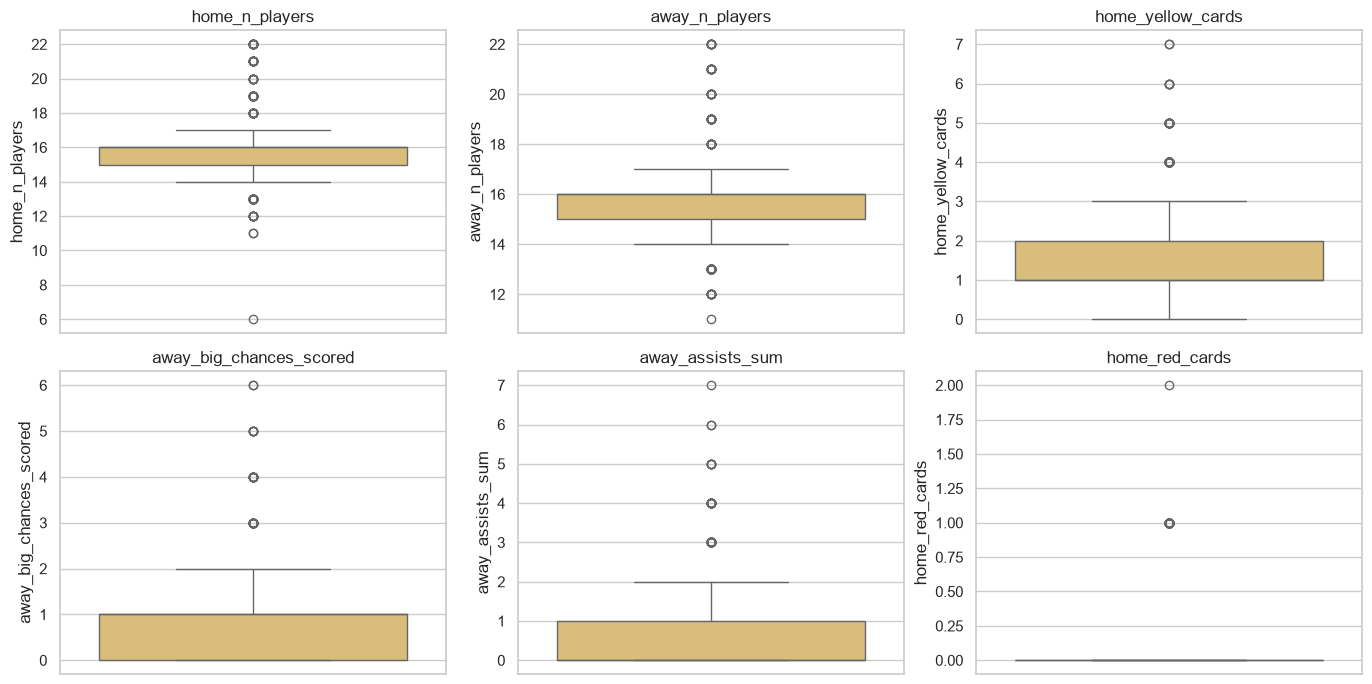

In [41]:
top = out_tbl.sort_values('pct', ascending=False)['feature'].head(6).tolist()
fig, axes = plt.subplots(2,3, figsize=(14,7))
for ax,c in zip(axes.ravel(), top):
    sns.boxplot(y=dfc[c], ax=ax, color='#e9c46a'); ax.set_title(c)
plt.tight_layout(); plt.show()

### Tratamento
1. **`attendance` < 100 → NaN** (placeholder impossível).
2. **Outliers legítimos mantidos** (jogos reais; boosting é robusto).
3. **Winsorização opcional** (`*_w`, percentis 1/99) para modelos sensíveis a escala.

In [42]:
if 'attendance' in dfc.columns:
    bad = int((dfc['attendance'] < 100).sum())
    dfc.loc[dfc['attendance'] < 100, 'attendance'] = np.nan
    print(f'attendance: {bad} valores < 100 -> NaN')

def winsorize(s, lo=0.01, hi=0.99):
    return s.clip(s.quantile(lo), s.quantile(hi))
CONT = [c for c in ['home_shots_total','home_passes_total','home_expected_goals',
                    'home_goals_sum','away_goals_sum'] if c in dfc.columns]
for c in CONT: dfc[c+'_w'] = winsorize(dfc[c])
print('Winsorizadas (paralelas):', [c+'_w' for c in CONT])

attendance: 4 valores < 100 -> NaN
Winsorizadas (paralelas): ['home_shots_total_w', 'home_passes_total_w', 'home_expected_goals_w', 'home_goals_sum_w', 'away_goals_sum_w']


## 6. Base limpa — resumo e exportação

In [43]:
print('='*60); print('RESUMO DA PREPARACAO'); print('='*60)
print(f'Linhas: {len(dfc)}  |  Colunas: {dfc.shape[1]} (eram {df.shape[1]})')
comp = int(((dfc.has_team_stats==1)&(dfc.has_player_stats==1)).sum())
print(f'Partidas completas (time+jogador): {comp} | com xG: {int(dfc.has_xg.sum())} | com ranking: {int(dfc.has_ranking.sum())}')
print(f'Total de celulas nulas: {int(dfc.isna().sum().sum())} ({dfc.isna().mean().mean()*100:.1f}%)')
dfc.to_csv(DATA_OUT, index=False)
print('Base limpa salva em:', DATA_OUT.resolve())

RESUMO DA PREPARACAO
Linhas: 1138  |  Colunas: 143 (eram 102)
Partidas completas (time+jogador): 983 | com xG: 588 | com ranking: 1099
Total de celulas nulas: 32043 (19.7%)
Base limpa salva em: C:\Users\Caio Falleiro\Códigos\WorldCupPrediction\output\worldcup_dataset_clean.csv


## 7. Decisões registradas (resumo CRISP-DM)

| Item | Decisão | Justificativa |
|---|---|---|
| Eventos duplicados (2 lados) | **Deduplicados por evento** | 1 partida = 1 linha; mantém cópia mais completa |
| **xG de TIME** (`expected_goals`, 48% nulo) | **Manter + flag `has_xg`** | preditor nº 1 da literatura; MNAR por competição → imputar Fase 4 |
| **Ranking FIFA** (`*_team_ranking`, `rank_diff`) | **Manter** (~3% nulo) | força relativa das seleções; alto valor em campo neutro |
| Stats simétricas (`away_*`) | **Manter** | antes só havia mandante; agora os 2 lados |
| **Features de forma** (`form_*`, `form_diff_*`) | **Construídas na Fase 3** (Seção 3.5) | preditores pré-jogo *leakage-safe* (`shift(1)` + `rolling(5)`); reaproveitadas na Fase 4 |
| xG de **JOGADOR** (`_xg_`/`_xa_`), `score_*_ht` | **Dropar** | 89–100% nulo (cobertura insuficiente) |
| `red_cards`/eventos raros | **Imputar 0** onde há stats de time | nulo = ausência do evento |
| Jogador/time/xG (MNAR) | **Flags + NaN preservado** | imputação na Fase 4 com indicador |
| Forma sem histórico (1ºs jogos) | **NaN + flag `has_form`** | sem janela passada suficiente para a média móvel |
| Outliers de desempenho | **Mantidos** | jogos reais; boosting robusto |
| `attendance` < 100 | → NaN | placeholder impossível |

**Próxima fase (4 — Modelagem):** treinar sobre as **features de forma** já construídas aqui
(`form_diff_*` + `rank_diff`), validadas pela Seção 4.4; imputar MNAR por mediana-da-competição
+ flags; derivar **Elo/força** e **dias de descanso**; tratar a colinearidade dos pares
redundantes da Seção 4 e calibrar as probabilidades.